In [ ]:
import marimo as mo

mo.md(
    """
    # ARD vs Isotropic RBF

    ARD is useful when only some columns matter. This example builds a
    problem with two signal columns and six nuisance columns, then compares a
    single-lengthscale `RBF()` against `RBF(ard=True)`.

    The key visual check is simple: ARD should assign high relevance to the
    two signal columns, low relevance to the nuisance columns, and reduce
    held-out prediction error.
    """
)

# ARD vs Isotropic RBF

ARD is useful when only some columns matter. This example builds a
problem with two signal columns and six nuisance columns, then compares a
single-lengthscale `RBF()` against `RBF(ard=True)`.

The key visual check is simple: ARD should assign high relevance to the
two signal columns, low relevance to the nuisance columns, and reduce
held-out prediction error.

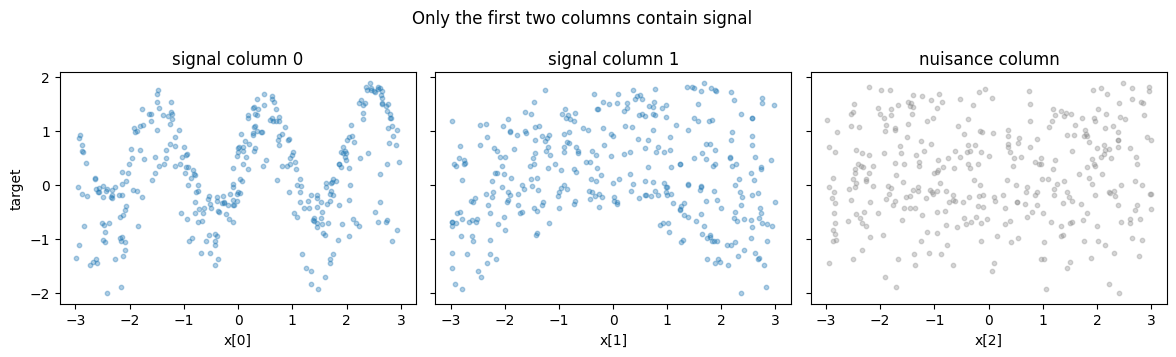

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

_rng = np.random.default_rng(4)
X_train = _rng.uniform(-3, 3, size=(340, 8)).astype(np.float32)
X_test = _rng.uniform(-3, 3, size=(140, 8)).astype(np.float32)

def signal(X):
    return (
        np.sin(3.2 * X[:, 0])
        + 0.7 * np.cos(0.75 * X[:, 1])
        + 0.15 * X[:, 0] * X[:, 1]
    ).astype(np.float32)

y_train = (signal(X_train) + 0.06 * _rng.standard_normal(340)).astype(np.float32)
y_test = signal(X_test).astype(np.float32)
dim_names = ["signal: fast wave", "signal: slow wave"] + [
    f"nuisance {idx}" for idx in range(1, 7)
]

_fig, _axes = plt.subplots(1, 3, figsize=(12, 3.6), sharey=True)
_feature_indices = [0, 1, 2]
_titles = ["signal column 0", "signal column 1", "nuisance column"]
for _ax, _feature_idx, _title in zip(_axes, _feature_indices, _titles):
    _ax.scatter(
        X_train[:, _feature_idx],
        y_train,
        s=10,
        alpha=0.35,
        color="tab:blue" if _feature_idx < 2 else "0.55",
    )
    _ax.set_title(_title)
    _ax.set_xlabel(f"x[{_feature_idx}]")
_axes[0].set_ylabel("target")
_fig.suptitle("Only the first two columns contain signal")
_fig.tight_layout()
mo.mpl.interactive(_fig)

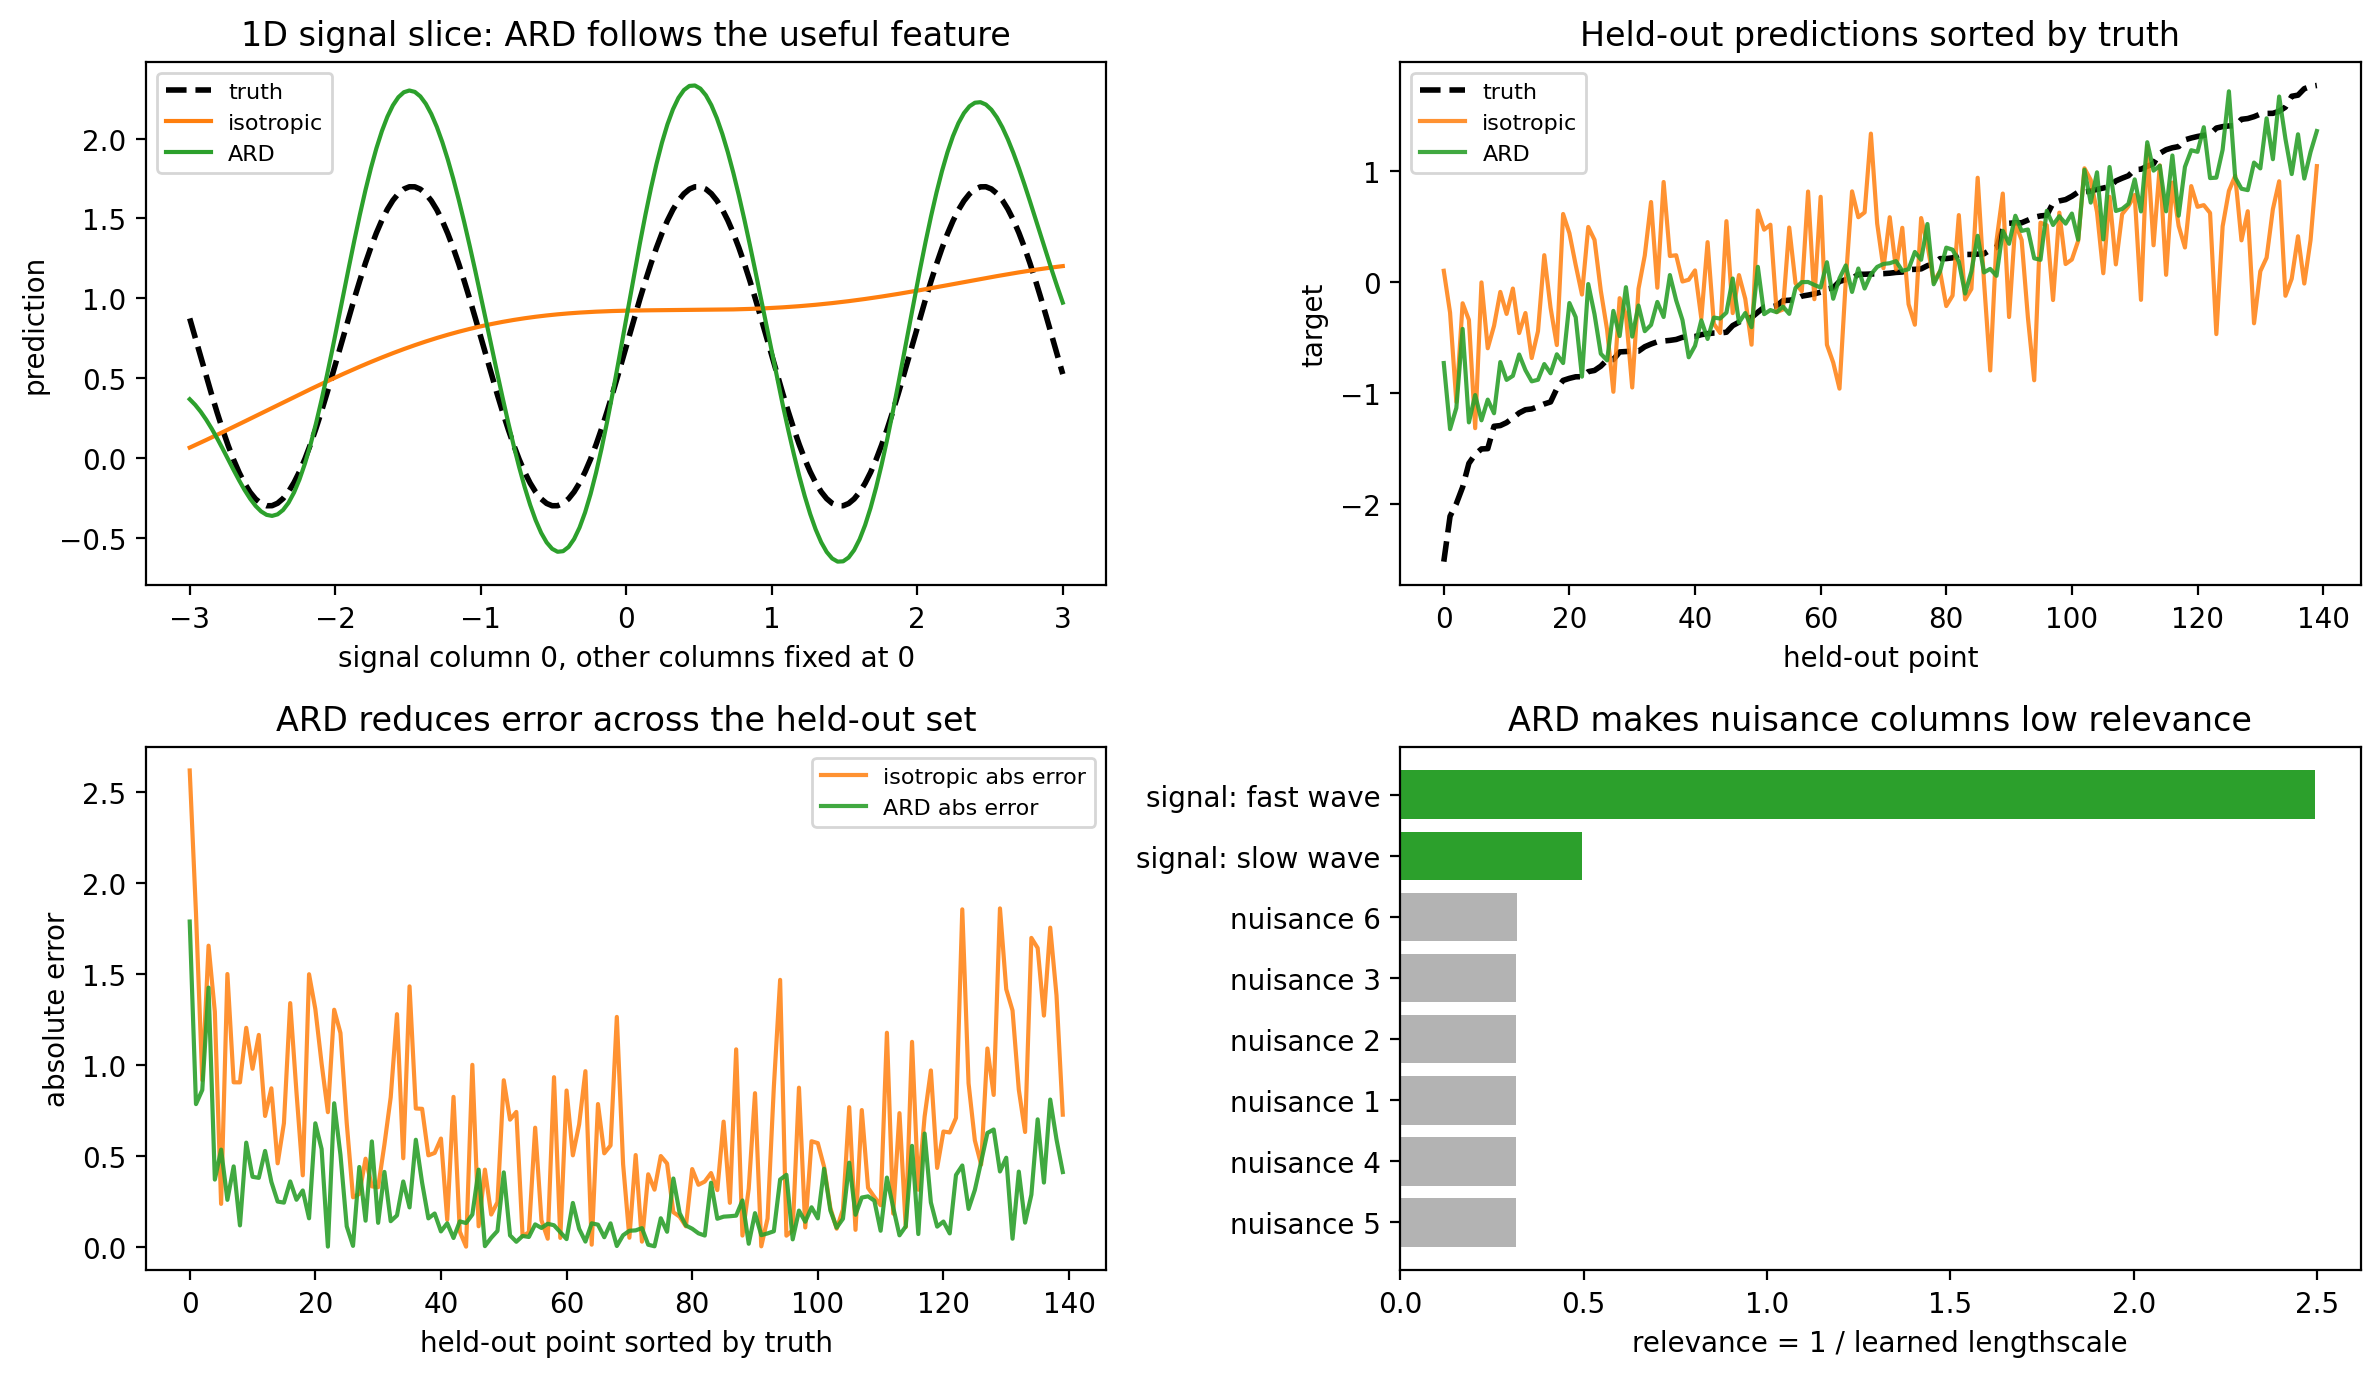

Accuracy Summary 
 Isotropic RBF: RMSE 0.8427 
 One shared lengthscale is forced to explain both the signal columns
and the six nuisance columns. 
 ARD RBF: RMSE 0.3712 
 One learned lengthscale per column lets the model downweight nuisance
dimensions. 
 ARD reaches 0.441x the isotropic RMSE. The two shortest
lengthscales are signal: fast wave, signal: slow wave , which are the two
columns that actually generate the target. The grey nuisance bars
should be much smaller than the green signal bars.
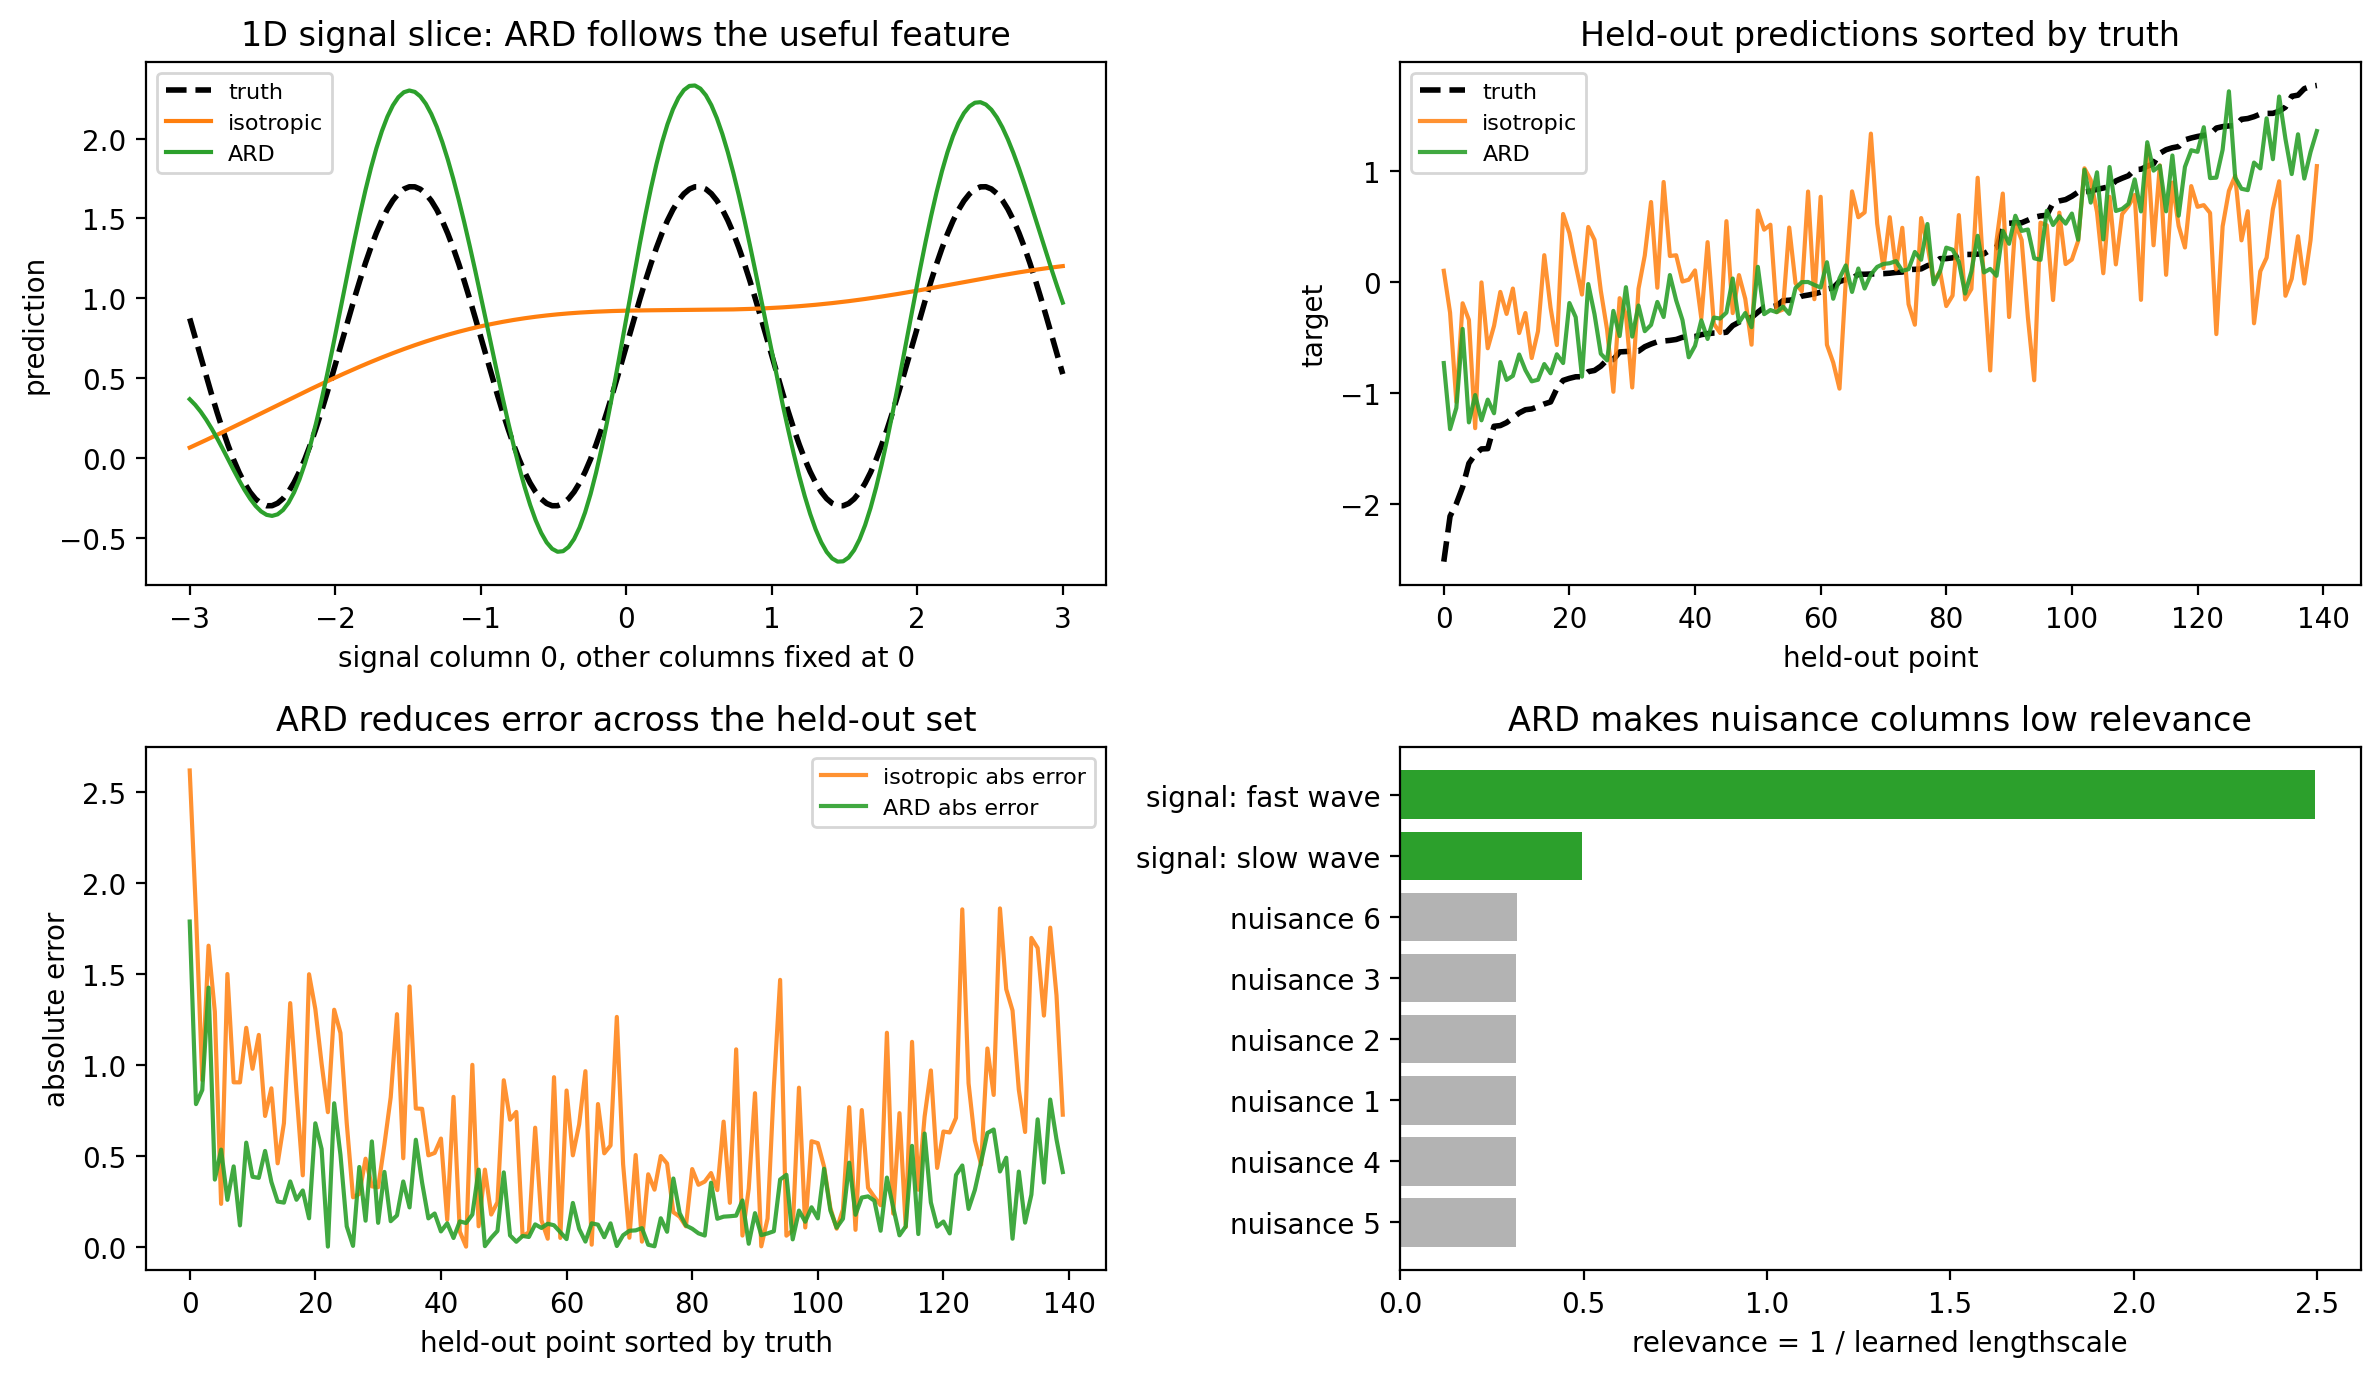

In [ ]:
from mojogp import RBF, SingleOutputGP

iso = SingleOutputGP(RBF())
iso.fit(
    X_train,
    y_train,
    max_iterations=60,
    learning_rate=0.035,
    method="materialized",
)
mean_iso = iso.predict(X_test, variance_method="mean_only").mean

ard = SingleOutputGP(RBF(ard=True))
ard.fit(
    X_train,
    y_train,
    max_iterations=60,
    learning_rate=0.035,
    method="materialized",
)
mean_ard = ard.predict(X_test, variance_method="mean_only").mean

iso_rmse = float(np.sqrt(np.mean((mean_iso - y_test) ** 2)))
ard_rmse = float(np.sqrt(np.mean((mean_ard - y_test) ** 2)))
rmse_ratio = ard_rmse / iso_rmse
ard_params = ard.get_learned_params()

def ard_feature_pairs(params):
    _pairs = []
    for _param_name, _value in params.items():
        if (
            "_ls_" not in _param_name
            and "_lengthscale_" not in _param_name
            and not _param_name.startswith("ls_")
        ):
            continue
        try:
            _feature_idx = int(_param_name.split("_")[-1])
        except ValueError:
            continue
        if 0 <= _feature_idx < len(dim_names):
            _pairs.append((dim_names[_feature_idx], float(_value), _feature_idx))
    return sorted(_pairs, key=lambda item: item[1])

ard_pairs = ard_feature_pairs(ard_params)
relevance_pairs = [(_name, 1.0 / max(_lengthscale, 1e-8), _idx) for _name, _lengthscale, _idx in ard_pairs]
relevance_pairs = sorted(relevance_pairs, key=lambda item: item[1])
shortest_signal_features = ", ".join(_name for _name, _, _idx in ard_pairs[:2])

_order = np.argsort(y_test)
_abs_iso = np.abs(mean_iso - y_test)
_abs_ard = np.abs(mean_ard - y_test)

_slice_x = np.linspace(-3, 3, 160, dtype=np.float32)
_slice_inputs = np.zeros((_slice_x.size, 8), dtype=np.float32)
_slice_inputs[:, 0] = _slice_x
_slice_truth = signal(_slice_inputs)
_slice_iso = iso.predict(_slice_inputs, variance_method="mean_only").mean
_slice_ard = ard.predict(_slice_inputs, variance_method="mean_only").mean

_fig, _axes = plt.subplots(2, 2, figsize=(12, 7))
_curve_ax, _sorted_ax, _error_ax, _rank_ax = _axes.ravel()

_curve_ax.plot(_slice_x, _slice_truth, "k--", linewidth=2, label="truth")
_curve_ax.plot(_slice_x, _slice_iso, color="tab:orange", label="isotropic")
_curve_ax.plot(_slice_x, _slice_ard, color="tab:green", label="ARD")
_curve_ax.set_title("1D signal slice: ARD follows the useful feature")
_curve_ax.set_xlabel("signal column 0, other columns fixed at 0")
_curve_ax.set_ylabel("prediction")
_curve_ax.legend(fontsize=8)

_sorted_ax.plot(y_test[_order], "k--", linewidth=2, label="truth")
_sorted_ax.plot(mean_iso[_order], color="tab:orange", alpha=0.85, label="isotropic")
_sorted_ax.plot(mean_ard[_order], color="tab:green", alpha=0.9, label="ARD")
_sorted_ax.set_title("Held-out predictions sorted by truth")
_sorted_ax.set_xlabel("held-out point")
_sorted_ax.set_ylabel("target")
_sorted_ax.legend(fontsize=8)

_error_ax.plot(_abs_iso[_order], color="tab:orange", alpha=0.85, label="isotropic abs error")
_error_ax.plot(_abs_ard[_order], color="tab:green", alpha=0.9, label="ARD abs error")
_error_ax.set_title("ARD reduces error across the held-out set")
_error_ax.set_xlabel("held-out point sorted by truth")
_error_ax.set_ylabel("absolute error")
_error_ax.legend(fontsize=8)

_labels = [_name for _name, _, _idx in relevance_pairs]
_values = [_rel for _, _rel, _idx in relevance_pairs]
_colors = ["tab:green" if _idx < 2 else "0.70" for _, _, _idx in relevance_pairs]
_rank_ax.barh(range(len(_labels)), _values, color=_colors)
_rank_ax.set_yticks(range(len(_labels)))
_rank_ax.set_yticklabels(_labels)
_rank_ax.set_xlabel("relevance = 1 / learned lengthscale")
_rank_ax.set_title("ARD makes nuisance columns low relevance")

_fig.tight_layout()

mo.vstack(
    [
        mo.mpl.interactive(_fig),
        mo.md(
            f"""
            ## Accuracy Summary

            **Isotropic RBF:** RMSE `{iso_rmse:.4f}`

            One shared lengthscale is forced to explain both the signal columns
            and the six nuisance columns.

            **ARD RBF:** RMSE `{ard_rmse:.4f}`

            One learned lengthscale per column lets the model downweight nuisance
            dimensions.

            ARD reaches `{rmse_ratio:.3f}x` the isotropic RMSE. The two shortest
            lengthscales are `{shortest_signal_features}`, which are the two
            columns that actually generate the target. The grey nuisance bars
            should be much smaller than the green signal bars.
            """
        ),
    ]
)